<a href="https://colab.research.google.com/github/fcoliveira-utfpr/climas_brasil/blob/main/climas_brasil_thornthwaite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Bibliotecas
___

In [1]:
# =========================================================
# REQUIRED LIBRARIES
# =========================================================
!pip install geobr geopandas rasterio elevation cartopy matplotlib-scalebar --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import geobr
from geobr import read_municipality
from matplotlib.colors import ListedColormap

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from matplotlib.lines import Line2D
import unicodedata

import matplotlib.patches as mpatches
from matplotlib_scalebar.scalebar import ScaleBar

import warnings
from cartopy.io import DownloadWarning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.7/341.7 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 108.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 93.6 MB/s eta 0:00:00


## 2. Carregar o CSV de classificação

In [2]:
url = "https://raw.githubusercontent.com/fcoliveira-utfpr/climas_brasil/refs/heads/main/thornthwaite_municipios_preenchido.csv"
df_th = pd.read_csv(url, sep=",")
df_th

,code_muni,name_muni,abbrev_state,thornthwaite_completo,th_classe,th_classe_codigo,th_subtipo,th_pety,th_petr,def_anual_mm,excedente_anual_mm,pet_anual_mm,indice_umidade_im,indice_hidrico_ih,indice_aridez_ia,preenchido_por_vizinho
0,1100015.0,Alta Floresta d'Oeste,RO,B1wA'a',B1,5.0,w,A',a',212.139999,557.433331,1200.913322,35.818516,46.417449,17.664888,False
1,1100023.0,Ariquemes,RO,B4rB4'a',B4,2.0,r,B4',a',152.420000,1189.166675,1122.466667,97.794857,105.942271,13.579022,False
2,1100031.0,Cabixi,RO,B1wA'b4',B1,5.0,w,A',b4',238.443335,600.599997,1283.699997,35.641816,46.786632,18.574693,False
3,1100049.0,Cacoal,RO,B3wA'a',B3,3.0,w,A',a',195.323335,997.233310,1165.989990,75.475717,85.526747,16.751716,False
4,1100056.0,Cerejeiras,RO,B1wA'b4',B1,5.0,w,A',b4',260.886671,518.200001,1270.053329,28.476599,40.801436,20.541395,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5565,5222005.0,Vianópolis,GO,B1wA'b4',B1,5.0,w,A',b4',418.139998,645.733327,1320.613327,29.898936,48.896472,31.662561,False
5566,5222054.0,Vicentinópolis,GO,B1wA'b4',B1,5.0,w,A',b4',444.010000,635.700009,1370.299995,26.949866,46.391302,32.402394,False
5567,5222203.0,Vila Boa,GO,C2w2A'b4',C2,6.0,w2,A',b4',519.769995,368.300001,1410.633324,4.000898,26.108840,36.846570,False
5568,5222302.0,Vila Propício,GO,C2w2A'b4',C2,6.0,w2,A',b4',459.106668,548.966671,1376.596664,19.868032,39.878541,33.350849,False


### 3. Legenda, paleta e utilitários

In [3]:
# Thornthwaite (1948) — classe de umidade (Im), do mais úmido (A) ao mais árido (E)
TH_CLASSE_LABELS = {1:'A', 2:'B4', 3:'B3', 4:'B2', 5:'B1', 6:'C2', 7:'C1', 8:'D', 9:'E'}
TH_CLASSE_NOMES = {
    1:'Super-úmido', 2:'Úmido (B4)', 3:'Úmido (B3)', 4:'Úmido (B2)', 5:'Úmido (B1)',
    6:'Subúmido úmido', 7:'Subúmido seco', 8:'Semiárido', 9:'Árido'
}
TH_CLASSE_COLORS = {
    1:'#08306b', 2:'#2171b5', 3:'#4292c6', 4:'#6baed6', 5:'#9ecae1',
    6:'#fee391', 7:'#fec44f', 8:'#fe9929', 9:'#cc4c02'
}

def normalize(s):
    if pd.isna(s):
        return ''
    return ''.join(c for c in unicodedata.normalize('NFKD', str(s)) if not unicodedata.combining(c)).upper().strip()

STATE_ABBR = {
    'ACRE':'AC','ALAGOAS':'AL','AMAPA':'AP','AMAZONAS':'AM','BAHIA':'BA','CEARA':'CE',
    'DISTRITO FEDERAL':'DF','ESPIRITO SANTO':'ES','GOIAS':'GO','MARANHAO':'MA','MATO GROSSO':'MT',
    'MATO GROSSO DO SUL':'MS','MINAS GERAIS':'MG','PARA':'PA','PARAIBA':'PB','PARANA':'PR',
    'PERNAMBUCO':'PE','PIAUI':'PI','RIO DE JANEIRO':'RJ','RIO GRANDE DO NORTE':'RN',
    'RIO GRANDE DO SUL':'RS','RONDONIA':'RO','RORAIMA':'RR','SANTA CATARINA':'SC','SAO PAULO':'SP',
    'SERGIPE':'SE','TOCANTINS':'TO',
}

In [4]:
municipios_gdf = geobr.read_municipality(code_muni='all', year=2020).to_crs(epsg=4326)
estados_gdf = geobr.read_state(code_state='all', year=2020).to_crs(epsg=4326)
print(f'geobr trouxe {len(municipios_gdf)} municípios e {len(estados_gdf)} estados.')

# ponto representativo interno (garantidamente dentro do polígono, mesmo em formatos côncavos)
municipios_gdf['pt_interno'] = municipios_gdf.geometry.representative_point()
municipios_gdf['lon_c'] = municipios_gdf['pt_interno'].x
municipios_gdf['lat_c'] = municipios_gdf['pt_interno'].y
municipios_gdf['municipio_norm'] = municipios_gdf['name_muni'].apply(normalize)

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'github.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'release-assets.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
municipalities_2020_simplified.parquet: 100%|██████████| 20.2M/20.2M [00:00<00:00, 136MB/s]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'github.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'release-assets.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
states_2020_simplified.parquet: 100%|██████████| 1.72M/1.72M [00:00<00:00, 26.3MB/s]


geobr trouxe 5570 municípios e 27 estados.


## 4. Funções de plotagem (estilo cartopy padrão)

In [5]:
def _base_map(ax, titulo):
    minx, miny, maxx, maxy = municipios_gdf.total_bounds
    dx = (maxx - minx) * 0.05; dy = (maxy - miny) * 0.05
    ax.set_extent([minx - dx, maxx + dx, miny - dy, maxy + dy], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='#F5F5F5')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    return minx, miny, maxx, maxy

def _decoracoes(ax, minx, miny, maxx, maxy):
    estados_gdf.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8,
                               transform=ccrs.PlateCarree(), zorder=5)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False; gl.right_labels = False
    gl.xlabel_style = {'size': 9}; gl.ylabel_style = {'size': 9}
    ax.annotate('N', xy=(0.95, 0.13), xytext=(0.95, 0.07), xycoords='axes fraction',
                textcoords='axes fraction', ha='center', va='center', fontsize=11, fontweight='bold',
                arrowprops=dict(arrowstyle='-|>', linewidth=1.3, color='black'))
    lat_media = (miny + maxy) / 2
    dx_m = 111320 * np.cos(np.deg2rad(lat_media))
    largura_km = (maxx - minx) * dx_m / 1000
    escolhas_km = [10, 20, 25, 50, 100, 150, 200, 250, 500, 750, 1000]
    fixo_km = min(escolhas_km, key=lambda x: abs(x - largura_km / 4))
    ax.add_artist(ScaleBar(dx=dx_m, units='m', fixed_value=fixo_km * 1000, location='lower left',
                            box_alpha=0.5, scale_formatter=lambda value, unit: f'{int(value/1000)} km'))

In [6]:
def plot_categorico(gdf, coluna_codigo, labels, nomes, colors, titulo, legenda_titulo, savepath=None):
    classes = sorted(gdf[coluna_codigo].dropna().unique().astype(int))
    fig = plt.figure(figsize=(11, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    minx, miny, maxx, maxy = _base_map(ax, titulo)
    for c in classes:
        gdf[gdf[coluna_codigo] == c].plot(ax=ax, color=colors[c], edgecolor='none',
                                           transform=ccrs.PlateCarree(), zorder=3)
    _decoracoes(ax, minx, miny, maxx, maxy)
    total = gdf[coluna_codigo].notna().sum()
    cont = gdf[coluna_codigo].value_counts()
    patches = [mpatches.Patch(facecolor=colors[c], edgecolor='black', linewidth=0.4,
                               label=f'{labels[c]} — {nomes[c]}  ({100*cont.get(c,0)/total:.1f}%)')
               for c in classes]
    ax.legend(handles=patches, title=legenda_titulo, loc='upper right', frameon=True, fontsize=8.5)
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()

def plot_categorico_texto(gdf, coluna_texto, titulo, legenda_titulo, savepath=None):
    """Mapa de coluna categórica textual (ex.: thornthwaite_completo, com dezenas de classes)."""
    dados = gdf.dropna(subset=[coluna_texto])
    classes = dados[coluna_texto].value_counts().index.tolist()
    base = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors) + list(plt.cm.tab20c.colors)
    cores = {cls: base[i % len(base)] for i, cls in enumerate(classes)}
    fig = plt.figure(figsize=(11, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    minx, miny, maxx, maxy = _base_map(ax, titulo)
    for cls in classes:
        dados[dados[coluna_texto] == cls].plot(ax=ax, color=cores[cls], edgecolor='none',
                                                transform=ccrs.PlateCarree(), zorder=3)
    _decoracoes(ax, minx, miny, maxx, maxy)
    total = dados[coluna_texto].notna().sum()
    cont = dados[coluna_texto].value_counts()
    patches = [mpatches.Patch(facecolor=cores[cls], edgecolor='black', linewidth=0.4,
                               label=f'{cls}  ({100*cont.get(cls,0)/total:.1f}%)') for cls in classes]
    ax.legend(handles=patches, title=legenda_titulo, loc='upper right', frameon=True, fontsize=7, ncol=1)
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()

In [7]:
def plot_continua(gdf, coluna, titulo, unidade, cmap_nome, savepath=None):
    dados = gdf.dropna(subset=[coluna])
    fig = plt.figure(figsize=(11, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    minx, miny, maxx, maxy = _base_map(ax, titulo)
    vmin, vmax = dados[coluna].quantile([0.02, 0.98])   # evita outlier esticar a escala
    dados.plot(column=coluna, cmap=cmap_nome, vmin=vmin, vmax=vmax, ax=ax, edgecolor='none',
               transform=ccrs.PlateCarree(), zorder=3)
    _decoracoes(ax, minx, miny, maxx, maxy)
    sm = plt.cm.ScalarMappable(cmap=cmap_nome, norm=plt.Normalize(vmin=vmin, vmax=vmax)); sm._A = []
    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.035, pad=0.02, shrink=0.6)
    cbar.set_label(f'{titulo} ({unidade})', fontsize=10)
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()

# 5. Merge dos dados com os polígonos

In [8]:
warnings.filterwarnings("ignore", category=DownloadWarning)
gdf_th_merged = municipios_gdf.merge(df_th, on='code_muni', how='left')
print('Municípios com classe de umidade:', gdf_th_merged['th_classe_codigo'].notna().sum(), 'de', len(gdf_th_merged))

Municípios com classe de umidade: 5570 de 5570


# 6. Capítulo 1 — Classe de umidade de Thornthwaite (Im)

/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/pytho

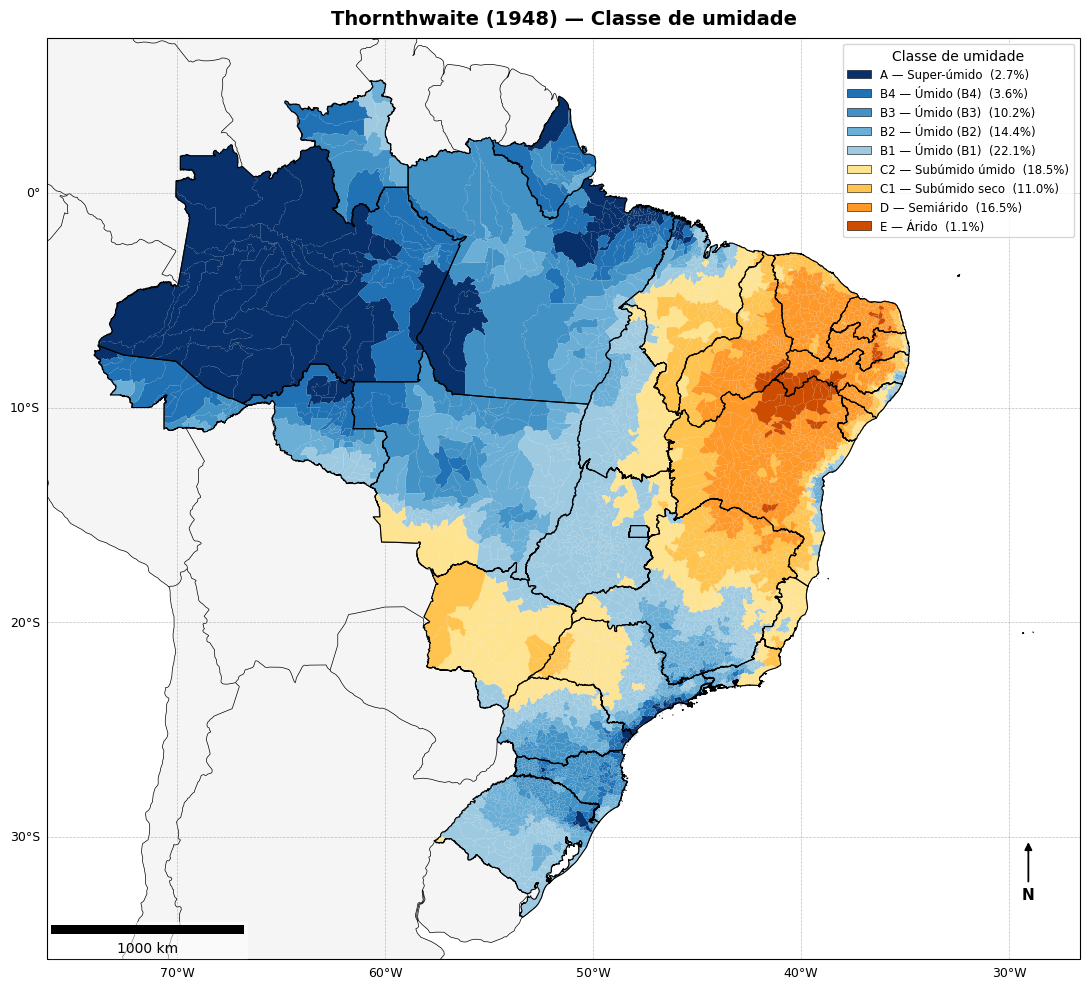

In [9]:
warnings.filterwarnings("ignore", category=DownloadWarning)

plot_categorico(gdf_th_merged, 'th_classe_codigo', TH_CLASSE_LABELS, TH_CLASSE_NOMES,
                TH_CLASSE_COLORS, 'Thornthwaite (1948) — Classe de umidade',
                'Classe de umidade', 'th_classe_umidade.png')

# 7. Capítulo 2 — Thornthwaite completo

In [ ]:
warnings.filterwarnings("ignore", category=DownloadWarning)

plot_categorico_texto(gdf_th_merged, 'thornthwaite_completo',
                       'Thornthwaite (1948) — Classificação completa', 'Thornthwaite completo',
                       'th_completo.png')

# 8. Capítulo 3 — Índices de Thornthwaite

In [ ]:
warnings.filterwarnings("ignore", category=DownloadWarning)

plot_continua(gdf_th_merged, 'indice_umidade_im', 'Índice de umidade (Im)',
              '', 'RdYlBu', 'indice_im.png')

In [ ]:
warnings.filterwarnings("ignore", category=DownloadWarning)

plot_continua(gdf_th_merged, 'indice_hidrico_ih', 'Índice hídrico (Ih)',
              '', 'YlGnBu', 'indice_ih.png')

In [ ]:
warnings.filterwarnings("ignore", category=DownloadWarning)

plot_continua(gdf_th_merged, 'indice_aridez_ia', 'Índice de aridez (Ia)',
              '', 'YlOrRd', 'indice_ia.png')

# 9. Capítulo 4 — Balanço hídrico

In [ ]:
warnings.filterwarnings("ignore", category=DownloadWarning)

plot_continua(gdf_th_merged, 'pet_anual_mm', 'Evapotranspiração potencial anual',
              'mm', 'YlOrRd', 'pet_anual.png')

In [ ]:
warnings.filterwarnings("ignore", category=DownloadWarning)

plot_continua(gdf_th_merged, 'def_anual_mm', 'Deficiência hídrica anual',
              'mm', 'YlOrRd', 'def_anual.png')

In [ ]:
warnings.filterwarnings("ignore", category=DownloadWarning)

plot_continua(gdf_th_merged, 'excedente_anual_mm', 'Excedente hídrico anual',
              'mm', 'YlGnBu', 'excedente_anual.png')